# Spikes Sym(bolic)

In [16]:
import sympy
import sympy as sp
from sympy import symbols, sympify, pprint
from sympy import Function, Eq, dsolve, Derivative, checkodesol,lambdify,re, im, Add
from sympy.matrices import Matrix, eye, zeros, ones, diag, GramSchmidt
from sympy.solvers import solve
from sympy.abc import x
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [17]:
sp.init_printing(use_unicode=True)

In [ ]:
import numpy as np

def make_bin_states(N, width=None):
    """
    Return a 2D array where row i is the binary representation of integer i.

    Parameters
    ----------
    N : int
        Number of integers (0 to N-1).
    width : int, optional
        Number of bits. If None, uses minimum required bits.

    Returns
    -------
    ndarray of shape (N, width)
        Binary matrix.
    """
    if width is None:
        # smallest number of bits needed to represent N-1
        width = max(1, int(np.ceil(np.log2(N))))

    # numbers 0 .. N-1
    x = np.arange(N, dtype=np.uint32)

    # generate bit mask for each bit position
    bit_mask = 1 << np.arange(width-1, -1, -1)

    # matrix where each entry is (x & mask) > 0
    return ((x[:, None] & bit_mask) > 0).astype(int)

states = make_bin_states(4)


array([[0, 0],
       [0, 1],
       [1, 0],
       [1, 1]])

In [72]:
def make_states_prob(N, prefix='p_'):
    _states = make_states(2**N)
    states = []
    for i in range(_states.shape[0]):
        state = _states[i]
        name = ''.join([str(state[j]) for j in range(0, state.shape[0])])
        s = sp.symbols(prefix+name)
        states.append((state, name, s))
    return states

t = 0
S_zs = make_states_prob(2, 'zs_'+str(t))
S_zy = make_states_prob(2, 'zy_'+str(t))
print(S_zs)
print(S_zy)


[(array([0, 0]), '00', zs_000), (array([0, 1]), '01', zs_001), (array([1, 0]), '10', zs_010), (array([1, 1]), '11', zs_011)]
[(array([0, 0]), '00', zy_000), (array([0, 1]), '01', zy_001), (array([1, 0]), '10', zy_010), (array([1, 1]), '11', zy_011)]


In [25]:

n = sp.symbols('n', integer=True, positive=True)
x = sp.MatrixSymbol('x', n, 1)
w = sp.MatrixSymbol('w', n, 1)

dot = sp.Lambda((x, w), (x.T * w)[0, 0])

k = sp.symbols('k')
f = sp.Lambda(x, k * x)

s0, s1 = sp.symbols('s0 s1')
s_ = sp.Matrix([s0, s1])
y = dot(w, s_)
s = sp.MatrixSymbol('s', n, 1)
f(y)


  n - 1                          
  ____                           
  ╲                              
   ╲                             
    ╲    ⎛⎡s₀⎤⎞                  
k⋅  ╱    ⎜⎢  ⎥⎟[i₁, 0]⋅(w)[i₁, 0]
   ╱     ⎝⎣s₁⎦⎠                  
  ╱                              
  ‾‾‾‾                           
  i₁ = 0                         

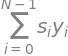

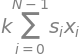

In [ ]:
#N = 2
N = sp.symbols('N', integer=True, positive=True)
a = sp.IndexedBase('a')
b = sp.IndexedBase('b')

x = sp.IndexedBase('x')
y = sp.IndexedBase('y')
z = sp.IndexedBase('z')
s = sp.IndexedBase('s')

#w = sp.MatrixSymbol('w', N, N)
#w = sp.Matrix(sp.symbols('w0:3_0:3'))
w = sp.IndexedBase('w')

i, j = sp.symbols('i j', integer=True)

i = sp.symbols('i', integer=True)
expr = x[i]      # single-index access

#x = sp.MatrixSymbol('x', N, 1)
#w = sp.MatrixSymbol('w', N, 1)
dot =  sp.Lambda((a, b), sp.summation(a[i] * b[i], (i, 0, N-1)))
f = sp.Lambda(x, k * x)
#x[0]
display(s)
display(w[0,:])
display(z)
display(y)
display(expr)
display(dot(s, y))
y = f(dot(s, x))
display(y)
y_ = y.subs(N, 2)


display(sp.simplify(y_))



In [200]:
from sympy import latex
from IPython.display import Math

def sdisplay_(x, expr):
    x__ = sp.Eq(sp.symbols(x), expr)
    display(x__)

def sdisplay(*args):
    def _latex(*args, sep=' = '):
        largs = []
        for arg in args:
            if isinstance(arg, str):
                largs.append(latex(sp.symbols(arg)))   
            else:
                largs.append(latex(arg))   
        ms = sep.join(largs)
        return ms
    ms = _latex(*args)
    display(Math(ms))

def ldisplay(*args):
    def _latex(args, sep=' = '):
        largs = []
        if isinstance(args, list):
            for arg in args:
                if isinstance(arg, str):
                    largs.append(latex(sp.symbols(arg)))   
                else:
                    largs.append(latex(arg))   
            ms = sep.join(largs)
            return ms
        else:
            if isinstance(args, str):
                return latex(sp.symbols(args))
            else:
                return latex(args)   

    largs = []                
    for arg in args:
        largs.append(_latex(arg))
    ms = '\ \ ;\ \ '.join(largs)
    display(Math(ms))

def mdisplay(*args):
    for arg in args:
        if isinstance(arg, dict):
            for key, value in arg.items():
                sdisplay(key, value)
        else:
           sdisplay(arg) 
            

    
a,b,c = sp.symbols('a b c')
sdisplay('x', a+b, b+c)
ldisplay(['x', a+b, b+c], ['y', c])
mdisplay({'x': a+b, 'y': c})


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [ ]:

x = sp.IndexedBase('x')
w = sp.IndexedBase('w')
zs = sp.IndexedBase('z^s')
s = sp.IndexedBase('s')
z = sp.IndexedBase('z')
N = sp.symbols('N', integer=True, positive=True)
i, j, k = sp.symbols('i j k', integer=True)


dot =  sp.Lambda((a, b), sp.summation(a[i] * b[i], (i, 0, N-1)))
dot_row = sp.Lambda((w, x, i), sp.summation(w[i, j] * x[j], (j, 0, N-1)) )
f = sp.Lambda(x, k * x)

y = dot_row(w, zs, i)

N_ = 2
y_  = y.subs(N, N_)
y_ = y_.subs(N, N_).doit()
sdisplay('y', y_)
pz = f(y)
pz_ = pz.subs(N, N_).doit()
sdisplay('p_z', pz_)
for _i, s_zs in enumerate(S_zs):
    zs_v = s_zs[0]
    d = {zs[i]: zs_v[i] for i in range(zs_v.shape[0])}
    sdisplay('d_'+s_zs[1], d)
    zs_p = pz_.subs(d)    
    sdisplay('p^z_s'+s_zs[1], zs_p)

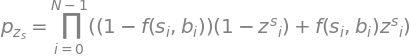

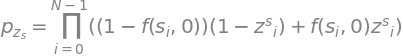

In [121]:
f = sp.Function('f')
idx = sp.Wild('idx')

zs = sp.IndexedBase('z^s')

term = zs[i] * f(s[i], b[i]) + (1 - zs[i]) * (1 - f(s[i], b[i]))

p_zs = sp.Product(term, (i, 0, N-1))

zs_v = np.array([1, 0])
d = {zs[i]: zs_v[i] for i in range(zs_v.shape[0])}
p_zs = p_zs.subs(d)
sdisplay('p_{z_s}', p_zs)
p_zs_ = p_zs.replace(lambda a: a.func == f, lambda a: k*(a.args[0] - a.args[1]))
p_zs_ = p_zs.replace(lambda a: getattr(a, "is_Indexed", False) and a.base == b, lambda a: sp.Integer(0))
sdisplay('p_{z_s}', p_zs_)
idx = sp.Wild('idx')
p_zs_ = p_zs_.subs(N, N_).doit()
p_zs_ = p_zs_.subs(b[idx], 0)
#p_zs_ = p_zs_.subs(b[idx], 0).doit()
sdisplay('p_{z_s}', p_zs_)



In [191]:
f2 = sp.Function('f')
idx = sp.Wild('idx')

a = sp.IndexedBase('a')
b = sp.IndexedBase('b')
x = sp.IndexedBase('x')
y = sp.IndexedBase('y')
w = sp.IndexedBase('w')
zs = sp.IndexedBase('z^s')
s = sp.IndexedBase('s')
z = sp.IndexedBase('z')
N = sp.symbols('N', integer=True, positive=True)
i, j, k = sp.symbols('i j k', integer=True)

term = zs[i] * f(s[i], b[i]) + (1 - zs[i]) * (1 - f(s[i], b[i]))

p_zs = sp.Product(term, (i, 0, N-1))

pp_zs = []
for _i, s_zs in enumerate(S_zs):
    zs_v = s_zs[0]
    __p_zs = f'p_{{z^s_{{{s_zs[1]}}}}}'
    terms = [
        f2(s[i], b[i]) if int(zs_i) == 1 else (1 - f2(s[i], b[i]))
        for i, zs_i in enumerate(zs_v)
    ]
    p_zs = sp.Mul(*terms)   # or use sp.prod in recent sympy versions
    p_zs_ = p_zs.replace(lambda a: a.func == f2, lambda a: k*(a.args[0] - a.args[1]))
    p_zs__ = p_zs_.replace(lambda a: getattr(a, "is_Indexed", False) and a.base == b, lambda a: sp.Integer(0))
    sdisplay(__p_zs, p_zs, p_zs_, p_zs__)
    pp_zs.append(p_zs__)



<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [220]:
def simplify_all(d):
    return {key: value.simplify() for key, value in d.items() }

def doit_all(d):
    return {key: value.doit() for key, value in d.items() }

def marginalize(S, pp, N_, prefix, simplify=True, doit=True):
    _q = []
    for j in range(0, N_):
        __q = f'p_{{{prefix}_{j}}}'
        _q.append(sp.symbols(__q))

    q = {}
    for j in range(0, N_):
        qj = _q[j]
        for _i, s in enumerate(S):
            s_v = s[0]
            if qj in q:
                q[qj] += pp[_i]
            else:
                q[qj] = pp[_i]
    if simplify:
        q = simplify_all(q)
    if doit:
        q = doit_all(q)
    return q
    
q_zs = marginalize(S_zs, pp_zs, N_, 'z^s', False, False)
mdisplay(q_zs)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [210]:
a = sp.IndexedBase('a')
b = sp.IndexedBase('b')
i, j, k = sp.symbols('i j k', integer=True)

dot =  sp.Lambda((a, b), sp.summation(a[i] * b[i], (i, 0, N-1)))
dot_row = sp.Lambda((w, x, i), sp.summation(w[i, j] * x[j], (j, 0, N_-1)) )

#display(z)
#display(W[0,:])
#display(dot(W, z))

by = sp.IndexedBase('b^y')
yy = {}
bby = {}
for _i in range(0, N_):
    y_ = dot_row(w, zs, _i) - by[_i]
    yy[y[_i]] = y_
    sdisplay(y[_i], y_)
    bby[by[_i]] = 0

display(yy)

f = sp.Function('f')

pp_zy = []
for _i, s_zy in enumerate(S_zy):
    z_v = s_zy[0]
    __p_z = f'p_{{z^y_{{{s_zy[1]}}}}}'
    terms = [ f(y[i]) if int(z_i) == 1 else (1 - f(y[i])) for i, z_i in enumerate(z_v) ]
    p_z = sp.Mul(*terms)   # or use sp.prod in recent sympy versions
    p_z_ = p_z.replace(lambda a: a.func == f, lambda a: k*(a.args[0]))
    p_z__ = p_z_.xreplace(yy)
    p_z___ = p_z__.xreplace(bby)
    pp_zy.append(p_z___)
    sdisplay(__p_z, p_z, p_z_, p_z__, p_z___)
 

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [212]:
q_zy = marginalize(S_zy, pp_zy, N_, 'z^y')
mdisplay(q_zy)


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [156]:
N, M = sp.symbols('N M', integer=True, positive=True)
N_ = 2
M_ = 2
w = sp.IndexedBase('w')
W = sp.Matrix(N_, M_, lambda i, j: w[i, j])
display(W)


⎡w[0, 0]  w[0, 1]⎤
⎢                ⎥
⎣w[1, 0]  w[1, 1]⎦

In [155]:
W = sp.MatrixSymbol('W', N, M)
display(W)
display(W[i,j])


In [150]:
w = sp.Matrix(sp.symbols('w0:3_0:3'))
display(w)

⎡w₀ ₀⎤
⎢    ⎥
⎢w₀ ₁⎥
⎢    ⎥
⎢w₀ ₂⎥
⎢    ⎥
⎢w₁ ₀⎥
⎢    ⎥
⎢w₁ ₁⎥
⎢    ⎥
⎢w₁ ₂⎥
⎢    ⎥
⎢w₂ ₀⎥
⎢    ⎥
⎢w₂ ₁⎥
⎢    ⎥
⎣w₂ ₂⎦